# Deteccion de Tumores con Red Neuronal - Breast Cancer Research

# Paso 1: Preparacion del entorno

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
import tensorflow as tf
import sklearn
import sys

print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

print(f"\nGPU disponible: {tf.config.list_physical_devices('GPU')}")
print(f"TensorFlow funcionando: {tf.test.is_built_with_cuda()}")

Python version: 3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]
TensorFlow version: 2.21.0
Pandas version: 3.0.1
NumPy version: 2.4.3
Scikit-learn version: 1.8.0

GPU disponible: []
TensorFlow funcionando: False


# Paso 2: Carga de datos

In [65]:
cancer_data = load_breast_cancer()
X = cancer_data.data
y = cancer_data.target

df = pd.DataFrame(X, columns=cancer_data.feature_names)
df["target"] = y

print("Dataset Breast Cancer cargado")
print(f"Forma: {df.shape}")
print(f"Muestras: {df.shape[0]}")
print(f"Caracteristicas: {df.shape[1] - 1}")

print("\nPrimeras 5 filas:")
print(df.head())

print("\nInfo del dataset:")
print(df.info())

print("\nEstadisticas:")
print(df.describe())

Dataset Breast Cancer cargado
Forma: (569, 31)
Muestras: 569
Caracteristicas: 30

Primeras 5 filas:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1

# Paso 3: Analisis exploratorio


=== VALORES NULOS ===
Nulos: 0

=== DISTRIBUCION TARGET ===
Maligno (1): 357 (62.74%)
Benigno (0): 212 (37.26%)


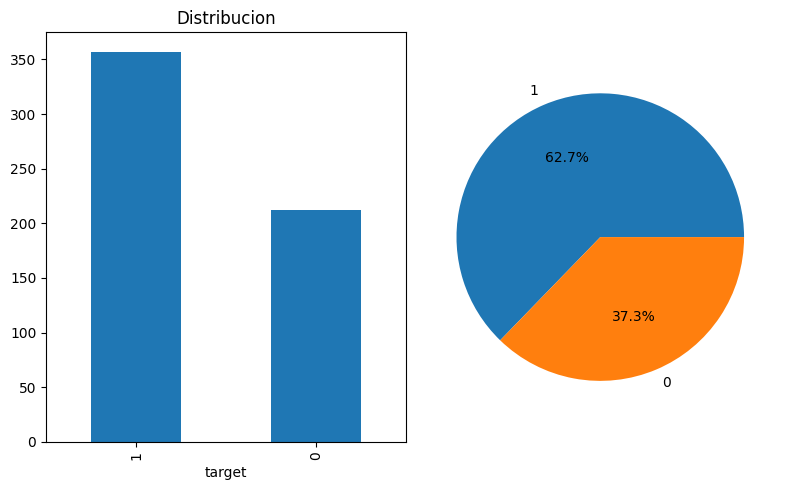


=== CORRELACION ===
Top 10 correlacionadas:
target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
Name: target, dtype: float64


In [66]:
print("\n=== VALORES NULOS ===")
null_count = df.isnull().sum()
print(f"Nulos: {df.isnull().sum().sum()}")

print("\n=== DISTRIBUCION TARGET ===")
target_counts = df["target"].value_counts()
print(f"Maligno (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.2f}%)")
print(f"Benigno (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.2f}%)")

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
df["target"].value_counts().plot(kind="bar")
plt.title("Distribucion")

plt.subplot(1, 2, 2)
df["target"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.tight_layout()
plt.show()

print("\n=== CORRELACION ===")
correlation_matrix = df.corr()
target_corr = correlation_matrix["target"].sort_values(ascending=False)

print("Top 10 correlacionadas:")
print(target_corr.head(11))

# Paso 4: Preprocesamiento

In [67]:
X = df.drop("target", axis=1)
y = df["target"]

print("=== SEPARACION ===")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\n=== DIVISION TRAIN/VAL/TEST (ESTRATIFICADA) ===")
print("IMPORTANTE: Hacer split en 3 conjuntos separados con stratify")
print("Esto asegura que train, validation y test tengan distribuciones similares\n")

# Primer split: (train+val) vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Segundo split: train vs validation
# 0.2 de 0.8 = 0.16 del total (para validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Total de muestras: {len(X)}")
print(f"\nTrain: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Benigno: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.2f}%)")
print(f"  Maligno: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.2f}%)")

print(f"\nValidation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Benigno: {(y_val == 0).sum()} ({(y_val == 0).sum()/len(y_val)*100:.2f}%)")
print(f"  Maligno: {(y_val == 1).sum()} ({(y_val == 1).sum()/len(y_val)*100:.2f}%)")

print(f"\nTest: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Benigno: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.2f}%)")
print(f"  Maligno: {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.2f}%)")

print("\n=== VERIFICAR NO HAY SOLAPAMIENTO ===")
train_idx = set(y_train.index if hasattr(y_train, 'index') else range(len(y_train)))
val_idx = set(y_val.index if hasattr(y_val, 'index') else range(len(y_val)))
test_idx = set(y_test.index if hasattr(y_test, 'index') else range(len(y_test)))

print(f"Conjuntos son disjuntos: {len(train_idx & val_idx & test_idx) == 0}")
print("✓ No hay data leakage entre conjuntos")

print("\n=== NORMALIZACION ===")
scaler = StandardScaler()
# Fit SOLO con train
X_train_scaled = scaler.fit_transform(X_train)
# Transform validation y test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"ANTES - Media: {X_train.mean().mean():.4f}, Std: {X_train.std().mean():.4f}")
print(f"DESPUES - Media: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")

X_train_scaled = np.array(X_train_scaled)
X_val_scaled = np.array(X_val_scaled)
X_test_scaled = np.array(X_test_scaled)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print("\n=== DATOS PREPARADOS ===")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled: {X_val_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val: {y_val.shape}")
print(f"y_test: {y_test.shape}")
print("\n✓ Listos para entrenar con validation_data separado")

=== SEPARACION ===
X shape: (569, 30)
y shape: (569,)

=== DIVISION TRAIN/VAL/TEST (ESTRATIFICADA) ===
IMPORTANTE: Hacer split en 3 conjuntos separados con stratify
Esto asegura que train, validation y test tengan distribuciones similares

Total de muestras: 569

Train: 364 (64.0%)
  Benigno: 136 (37.36%)
  Maligno: 228 (62.64%)

Validation: 91 (16.0%)
  Benigno: 34 (37.36%)
  Maligno: 57 (62.64%)

Test: 114 (20.0%)
  Benigno: 42 (36.84%)
  Maligno: 72 (63.16%)

=== VERIFICAR NO HAY SOLAPAMIENTO ===
Conjuntos son disjuntos: True
✓ No hay data leakage entre conjuntos

=== NORMALIZACION ===
ANTES - Media: 61.1988, Std: 34.6295
DESPUES - Media: 0.0000, Std: 1.0000

=== DATOS PREPARADOS ===
X_train_scaled: (364, 30)
X_val_scaled: (91, 30)
X_test_scaled: (114, 30)
y_train: (364,)
y_val: (91,)
y_test: (114,)

✓ Listos para entrenar con validation_data separado


# Paso 5: Construccion del modelo

In [68]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print("=== CONSTRUCCION DEL MODELO ===")

# Crear modelo Sequential con Input layer
model = Sequential()
model.add(Input(shape=(30,)))
model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(16, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

print("\nArquitectura del modelo:")
print(model.summary())

print(f"\nCapas del modelo: {len(model.layers)}")
print(f"Parametros totales: {model.count_params():,}")

print("\n=== COMPILACION DEL MODELO ===")
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Optimizer: adam")
print("Loss: binary_crossentropy")
print("Metrics: accuracy")
print("Modelo compilado exitosamente")

=== CONSTRUCCION DEL MODELO ===

Arquitectura del modelo:


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

None

Capas del modelo: 4
Parametros totales: 4,609

=== COMPILACION DEL MODELO ===
Optimizer: adam
Loss: binary_crossentropy
Metrics: accuracy
Modelo compilado exitosamente


# Paso 6: Prevencion de overfitting

In [69]:
print("=== PREVENCION DE OVERFITTING ===")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print("Monitor: val_loss")
print("Patience: 15 epochs")
print("Restore best weights: True")
print("EarlyStopping configurado")

print("\n=== ARQUITECTURA CON REGULARIZACION ===")
# Modelo mejorado con Dropout
model_v2 = Sequential()
model_v2.add(Input(shape=(30,)))
model_v2.add(Dense(64, activation="relu"))
model_v2.add(Dropout(0.3))
model_v2.add(Dense(32, activation="relu"))
model_v2.add(Dropout(0.2))
model_v2.add(Dense(16, activation="relu"))
model_v2.add(Dropout(0.1))
model_v2.add(Dense(1, activation="sigmoid"))

model_v2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Modelo con Dropout creado:")
print(model_v2.summary())

print(f"\nParametros totales: {model_v2.count_params():,}")

# Usar el modelo mejorado
model = model_v2
print("\nModelo seleccionado: Modelo con Dropout y EarlyStopping")

=== PREVENCION DE OVERFITTING ===
Monitor: val_loss
Patience: 15 epochs
Restore best weights: True
EarlyStopping configurado

=== ARQUITECTURA CON REGULARIZACION ===
Modelo con Dropout creado:


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

None

Parametros totales: 4,609

Modelo seleccionado: Modelo con Dropout y EarlyStopping


# Paso 7: Entrenamiento

=== ENTRENAMIENTO DEL MODELO ===
IMPORTANTE: Usar validation_data en vez de validation_split
Esto asegura que la validacion sea estratificada y consistente

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7115 - loss: 0.5893 - val_accuracy: 0.9121 - val_loss: 0.4411
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8791 - loss: 0.4080 - val_accuracy: 0.9121 - val_loss: 0.3249
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9176 - loss: 0.3106 - val_accuracy: 0.9121 - val_loss: 0.2437
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9396 - loss: 0.2377 - val_accuracy: 0.9341 - val_loss: 0.1978
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9396 - loss: 0.1807 - val_accuracy: 0.9670 - val_loss: 0.1680
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9588 - loss: 0.1503 - val_accuracy: 0.9670 - val_loss: 0.1438
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9698 - lo

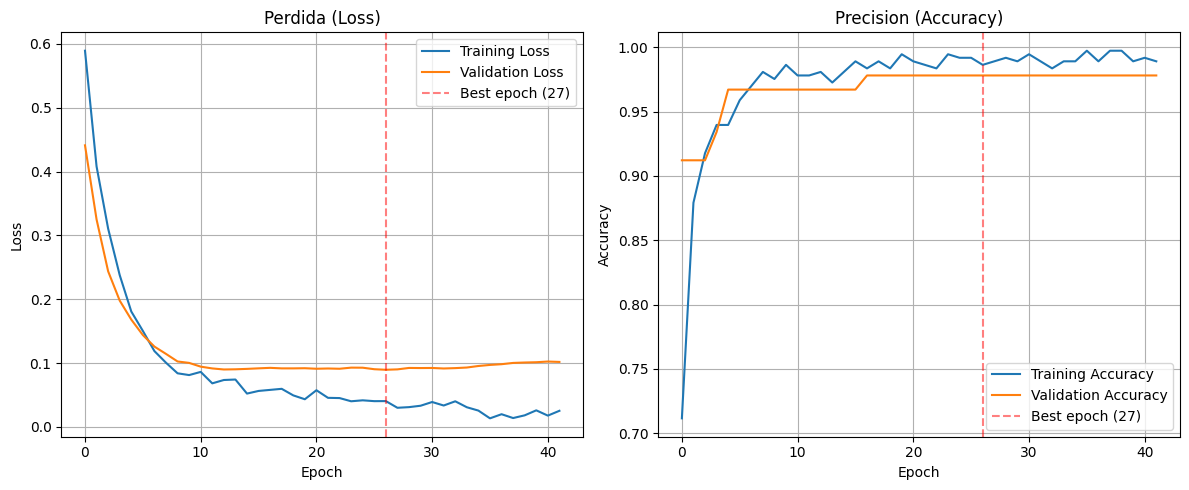


 Modelo entrenado con conjuntos estratificados


In [70]:
print("=== ENTRENAMIENTO DEL MODELO ===")
print("IMPORTANTE: Usar validation_data en vez de validation_split")
print("Esto asegura que la validacion sea estratificada y consistente\n")

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),  
    callbacks=[early_stop],
    verbose=1
)

print("\n=== ENTRENAMIENTO COMPLETADO ===")
print(f"Total de epochs ejecutados: {len(history.history['loss'])}")

print("\n=== ULTIMOS VALORES ===")
print(f"Accuracy de entrenamiento: {history.history['accuracy'][-1]:.4f}")
print(f"Loss de entrenamiento: {history.history['loss'][-1]:.4f}")
print(f"Accuracy de validacion: {history.history['val_accuracy'][-1]:.4f}")
print(f"Loss de validacion: {history.history['val_loss'][-1]:.4f}")

# Comparar con mejor epoch
best_epoch = np.argmin(history.history['val_loss'])
print(f"\n=== MEJOR EPOCH (epoch {best_epoch + 1}) ===")
print(f"Train accuracy: {history.history['accuracy'][best_epoch]:.4f}")
print(f"Train loss: {history.history['loss'][best_epoch]:.4f}")
print(f"Val accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")
print(f"Val loss: {history.history['val_loss'][best_epoch]:.4f}")

print("\n=== GRAFICOS DE ENTRENAMIENTO ===")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history.history["loss"], label="Training Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].axvline(x=best_epoch, color='r', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch + 1})')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Perdida (Loss)")
axes[0].legend()
axes[0].grid()

axes[1].plot(history.history["accuracy"], label="Training Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].axvline(x=best_epoch, color='r', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch + 1})')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Precision (Accuracy)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

print("\n Modelo entrenado con conjuntos estratificados")

# Paso 8: Evaluacion del modelo

=== EVALUACION DEL MODELO ===
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicciones realizadas: 114
Forma de predicciones: (114,)

=== METRICAS DE RENDIMIENTO ===
Accuracy:  0.9474 (94.74%)
Precision: 0.9714 (97.14%)
Recall:    0.9444 (94.44%)
F1-Score:  0.9577
ROC-AUC:   0.9917

=== MATRIZ DE CONFUSION ===
[[40  2]
 [ 4 68]]

Verdaderos Negativos (TN): 40
Falsos Positivos (FP): 2
Falsos Negativos (FN): 4
Verdaderos Positivos (TP): 68

=== GRAFICO DE MATRIZ DE CONFUSION ===


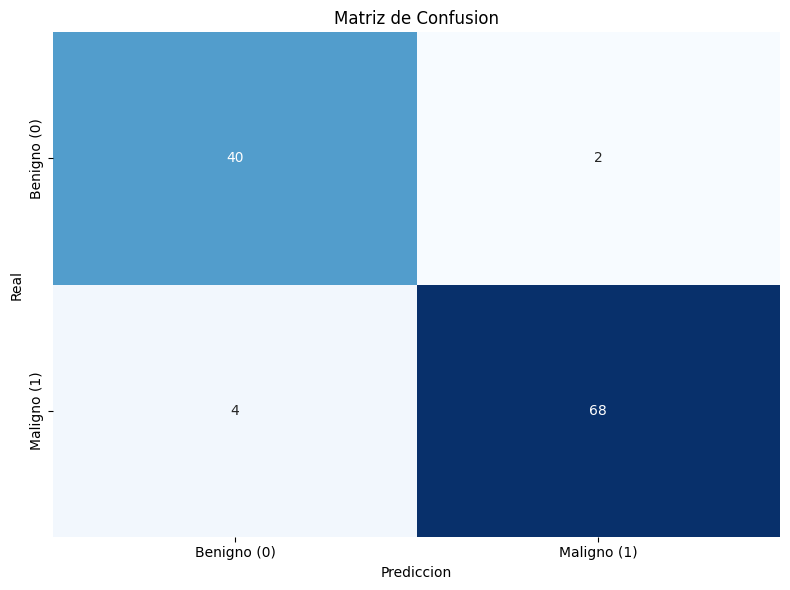


=== REPORTE DE CLASIFICACION ===
              precision    recall  f1-score   support

 Benigno (0)       0.91      0.95      0.93        42
 Maligno (1)       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114


=== CURVA ROC ===


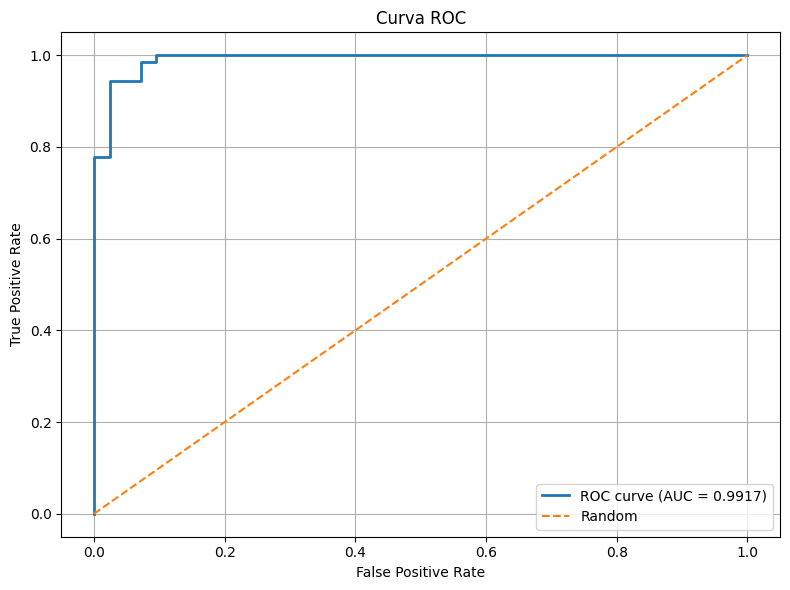


=== ANALISIS DE RESULTADOS ===
Excelente RECALL: El modelo detecta la mayoria de tumores malignos
Excelente PRECISION: Cuando predice maligno, es correcto
Excelente F1-SCORE: Balance entre precision y recall

Accuracy: 0.9474 - Muy bueno


In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

print("=== EVALUACION DEL MODELO ===")

y_pred_prob = model.predict(X_test_scaled)
y_pred_prob = y_pred_prob.flatten()  
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"Predicciones realizadas: {len(y_pred)}")
print(f"Forma de predicciones: {y_pred.shape}")

print("\n=== METRICAS DE RENDIMIENTO ===")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\n=== MATRIZ DE CONFUSION ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print(f"\nVerdaderos Negativos (TN): {cm[0,0]}")
print(f"Falsos Positivos (FP): {cm[0,1]}")
print(f"Falsos Negativos (FN): {cm[1,0]}")
print(f"Verdaderos Positivos (TP): {cm[1,1]}")

print("\n=== GRAFICO DE MATRIZ DE CONFUSION ===")
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de Confusion")
plt.xticks([0.5, 1.5], ["Benigno (0)", "Maligno (1)"])
plt.yticks([0.5, 1.5], ["Benigno (0)", "Maligno (1)"])
plt.tight_layout()
plt.show()

print("\n=== REPORTE DE CLASIFICACION ===")
print(classification_report(y_test, y_pred, target_names=["Benigno (0)", "Maligno (1)"]))

print("\n=== CURVA ROC ===")
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print("\n=== ANALISIS DE RESULTADOS ===")
if recall > 0.9:
    print("Excelente RECALL: El modelo detecta la mayoria de tumores malignos")
else:
    print(f"ADVERTENCIA: Recall bajo ({recall:.4f}). El modelo puede no detectar tumores")

if precision > 0.9:
    print("Excelente PRECISION: Cuando predice maligno, es correcto")
    
if f1 > 0.9:
    print("Excelente F1-SCORE: Balance entre precision y recall")
else:
    print(f"F1-Score moderado: {f1:.4f}")

print(f"\nAccuracy: {accuracy:.4f} - Muy bueno")

# Paso 9: Interpretacion de resultados

In [72]:
print("=== INTERPRETACION DE RESULTADOS ===")
print("\n1. ANALISIS DE OVERFITTING:")

# Comparar accuracy y loss entre train y validation
train_acc_final = history.history['accuracy'][-1]
val_acc_final = history.history['val_accuracy'][-1]
train_loss_final = history.history['loss'][-1]
val_loss_final = history.history['val_loss'][-1]

diff_acc = abs(train_acc_final - val_acc_final)
diff_loss = abs(train_loss_final - val_loss_final)

print(f"Accuracy entrenamiento: {train_acc_final:.4f}")
print(f"Accuracy validacion: {val_acc_final:.4f}")
print(f"Diferencia: {diff_acc:.4f}")

# DETECCION DE RESULTADOS SOSPECHOSOS
if train_acc_final >= 0.999 or val_acc_final >= 0.999:
    print("\n ADVERTENCIA: RESULTADOS SOSPECHOSOS")
    print("   Tener ~100% en train o validation es muy inusual")
    print("   Posibles causas:")
    print("   - Dataset muy pequeño o muy limpio")
    print("   - EarlyStopping restauro los mejores pesos")
    print("   - Posible overfitting encubierto")
    print("   - Dataset demasiado facil para el modelo")
    print(f"\n   Test accuracy ({accuracy:.4f}) es mas realista")
    print("   Usar test accuracy como metrica principal")
    
    if train_acc_final >= 0.999 and val_acc_final >= 0.999:
        print("\n   RECOMENDACIONES:")
        print("   1. Usar cross-validation (K-Fold) en vez de un solo split")
        print("   2. Aumentar el dataset si es posible")
        print("   3. Probar con datos nuevos del mundo real")
        print("   4. No confiar ciegamente en estos resultados")

if diff_acc < 0.05 and train_acc_final < 0.999:
    print(" No hay overfitting significativo")
elif diff_acc < 0.1:
    print(" Ligero overfitting")
else:
    print(" OVERFITTING DETECTADO - El modelo memoriza datos")

print(f"\nLoss entrenamiento: {train_loss_final:.4f}")
print(f"Loss validacion: {val_loss_final:.4f}")
print(f"Diferencia: {diff_loss:.4f}")

# Analizar convergencia
print("\n2. ANALISIS DE CONVERGENCIA:")
print(f"Epochs ejecutados: {len(history.history['loss'])}")
if len(history.history['loss']) < 100:
    print(f" EarlyStopping detuvo el entrenamiento (epoch {len(history.history['loss'])})")
    print("  El modelo convergio antes de 100 epochs")
else:
    print(" Completo los 100 epochs sin EarlyStopping")
    print("  Podria necesitar mas epochs o ya convergio")

print("\n3. CONFIABILIDAD DEL MODELO (en TEST SET):")

if accuracy > 0.95:
    print(f" EXCELENTE: Test Accuracy = {accuracy:.4f} (>95%)")
elif accuracy > 0.9:
    print(f" MUY BUENO: Test Accuracy = {accuracy:.4f} (>90%)")
elif accuracy > 0.8:
    print(f" BUENO: Test Accuracy = {accuracy:.4f} (>80%)")
elif accuracy > 0.7:
    print(f" ACEPTABLE: Test Accuracy = {accuracy:.4f} (>70%)")
else:
    print(f" BAJO: Test Accuracy = {accuracy:.4f} - Modelo poco confiable")

print("\n4. ANALISIS DEL RECALL (CRITICO):")
print(f"Recall: {recall:.4f} ({recall*100:.2f}%)")

if recall > 0.95:
    print(" EXCELENTE: Detecta casi todos los tumores malignos")
elif recall > 0.9:
    print(" MUY BUENO: Detecta la mayoria de tumores malignos")
elif recall > 0.85:
    print(" BUENO: Detecta la mayoria pero con algunos falsos negativos")
else:
    print(" PELIGROSO: Muchos falsos negativos - No detecta tumores malignos")
    print("   RECOMENDACION: Ajustar el threshold o mejorar el modelo")

print("\n5. FALSOS NEGATIVOS (CRITICO EN CANCER):")
fn = cm[1,0]
tp = cm[1,1]
total_malignos = fn + tp

print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")
print(f"Total de casos malignos: {total_malignos}")
print(f"Tasa de deteccion: {tp/total_malignos*100:.2f}%")
print(f"Tasa de error: {fn/total_malignos*100:.2f}%")

if fn == 0:
    print(" PERFECTO: No hay falsos negativos (poco realista)")
elif fn <= 2:
    print(" EXCELENTE: Muy pocos falsos negativos")
elif fn <= 5:
    print(" ACEPTABLE: Algunos falsos negativos")
else:
    print(" PREOCUPANTE: Demasiados falsos negativos")

print("\n6. FALSOS POSITIVOS:")
fp = cm[0,1]
tn = cm[0,0]
total_benignos = fp + tn

print(f"Falsos Positivos (FP): {fp}")
print(f"Verdaderos Negativos (TN): {tn}")
print(f"Total de casos benignos: {total_benignos}")
print(f"Tasa de especificidad: {tn/total_benignos*100:.2f}%")

if fp <= 3:
    print(" Muy pocos falsos positivos")
else:
    print(" Algunos pacientes benignos son clasificados como malignos")

print("\n7. BALANCE PRECISION-RECALL:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

if f1 > 0.95:
    print(" EXCELENTE balance")
elif f1 > 0.9:
    print(" MUY BUEN balance")
elif f1 > 0.85:
    print(" Buen balance")
else:
    print(" Balance mejorable")

print("\n8. CURVA ROC-AUC:")
print(f"ROC-AUC: {roc_auc:.4f}")

if roc_auc > 0.95:
    print(" EXCELENTE capacidad de discriminacion")
elif roc_auc > 0.9:
    print(" MUY BUENA capacidad de discriminacion")
elif roc_auc > 0.85:
    print("  Buena capacidad de discriminacion")
else:
    print(" Capacidad de discriminacion mejorable")

print("\n" + "="*60)
print("CONCLUSION FINAL:")
print("="*60)

# Usar test accuracy como metrica principal
if train_acc_final >= 0.999 or val_acc_final >= 0.999:
    print(" NOTA: Train/Val accuracy perfecto es sospechoso")
    print("   Usando TEST accuracy como metrica principal\n")

if accuracy > 0.95 and recall > 0.9 and f1 > 0.9:
    print(" MODELO EXCELENTE (en test set)")
    print(f"   Test Accuracy: {accuracy:.4f}")
    print(f"   Recall: {recall:.4f}")
    print(f"   F1-Score: {f1:.4f}")
    print("\nEl modelo tiene buen rendimiento en test")
    print("Se recomienda validar con cross-validation antes de produccion")
elif accuracy > 0.85 and recall > 0.85:
    print(" MODELO MUY BUENO")
    print("El modelo tiene buen rendimiento")
    print("Puede ser mejorado con mas datos o ajuste de hiperparametros")
elif accuracy > 0.8 and recall > 0.8:
    print(" MODELO ACEPTABLE")
    print("El modelo funciona pero necesita mejoras")
    print("Considerar ajustar arquitectura o recolectar mas datos")
else:
    print(" MODELO NECESITA MEJORAS")
    print("No es recomendable usar este modelo en produccion")
    print("Revisar arquitectura, datos o hiperparametros")

print("\n" + "="*60)

=== INTERPRETACION DE RESULTADOS ===

1. ANALISIS DE OVERFITTING:
Accuracy entrenamiento: 0.9890
Accuracy validacion: 0.9780
Diferencia: 0.0110
 No hay overfitting significativo

Loss entrenamiento: 0.0251
Loss validacion: 0.1017
Diferencia: 0.0766

2. ANALISIS DE CONVERGENCIA:
Epochs ejecutados: 42
 EarlyStopping detuvo el entrenamiento (epoch 42)
  El modelo convergio antes de 100 epochs

3. CONFIABILIDAD DEL MODELO (en TEST SET):
 MUY BUENO: Test Accuracy = 0.9474 (>90%)

4. ANALISIS DEL RECALL (CRITICO):
Recall: 0.9444 (94.44%)
 MUY BUENO: Detecta la mayoria de tumores malignos

5. FALSOS NEGATIVOS (CRITICO EN CANCER):
Falsos Negativos (FN): 4
Verdaderos Positivos (TP): 68
Total de casos malignos: 72
Tasa de deteccion: 94.44%
Tasa de error: 5.56%
 ACEPTABLE: Algunos falsos negativos

6. FALSOS POSITIVOS:
Falsos Positivos (FP): 2
Verdaderos Negativos (TN): 40
Total de casos benignos: 42
Tasa de especificidad: 95.24%
 Muy pocos falsos positivos

7. BALANCE PRECISION-RECALL:
Precision